In [6]:
import numpy as np
from astropy.io import fits
from astropy.table import Table 
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm 

/home/elettra/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [7]:
catalog = fits.open('3DHST_Allfields.fits')
print("File aperto con successo!")
print("Numero di estensioni:", len(catalog))

File aperto con successo!
Numero di estensioni: 2


In [8]:
catalog.info()

Filename: 3DHST_Allfields.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (1183,)   uint8   
  1  /Volumes/T7 Archive/environment/3DHST_V415/analysis/ALL5phot_zbest_s    1 BinTableHDU     46   16859R x 16C   [J, I, 3A, D, D, D, E, E, E, E, E, E, E, E, D, D]   


In [9]:
data = catalog[1].data
print(data.names)  

['id', 'fieldnr', 'field', 'ra', 'dec', 'm_F140W', 'z_best', 'z_best_l68', 'z_best_u68', 'ltau', 'lage', 'Av', 'lmass', 'lsfr', 'UmV', 'VmJ']


REDSHIFT HISTOGRAM

In [10]:
table = Table(catalog[1].data)
valid_z_mask = table['z_best'] > 0 #seleziono i redshift validi
table_clean = table[valid_z_mask]
z = table_clean['z_best']

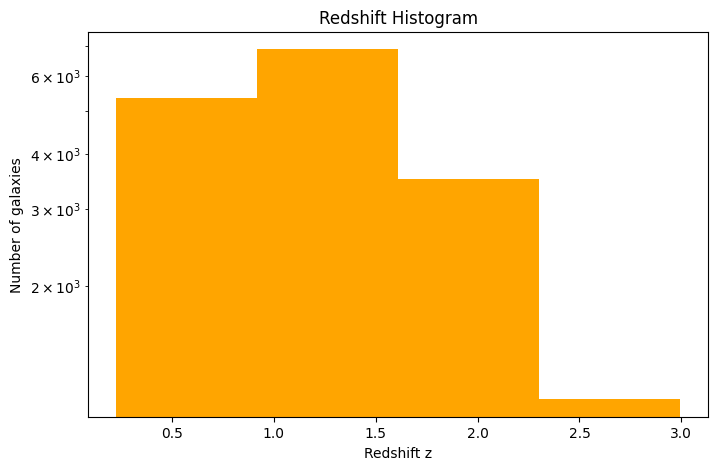

In [11]:

plt.figure(figsize=(8,5))
plt.hist(z, bins=4, color='orange')
plt.yscale('log')
plt.xlabel('Redshift z')
plt.ylabel('Number of galaxies')
plt.title('Redshift Histogram')
plt.show()


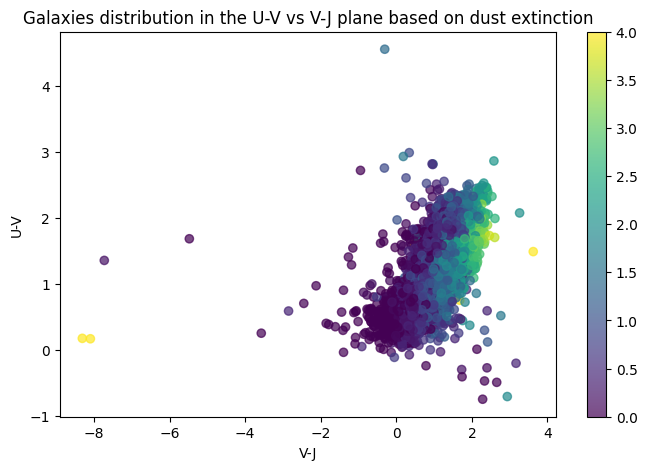

In [12]:
VmJ = table['VmJ']
UmV = table['UmV']
dust = table['Av']

plt.figure(figsize=(8,5))

plt.scatter(VmJ, UmV, c = dust, cmap='viridis', alpha = 0.7)
plt.xlabel('V-J')
plt.ylabel('U-V')
plt.colorbar()

plt.title('Galaxies distribution in the U-V vs V-J plane based on dust extinction')
plt.show()

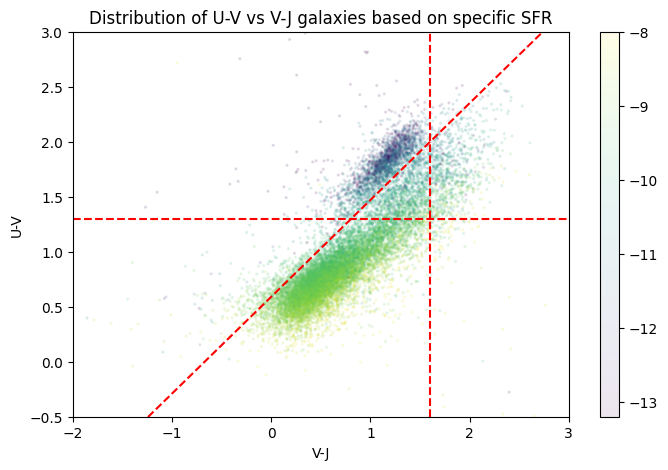

In [13]:
lmass = table['lmass']
lsfr = table['lsfr']
specsfr = lsfr - lmass

plt.figure(figsize=(8,5))

plt.scatter(VmJ, UmV, c = specsfr, s=2, vmin = -8, vmax =-12, cmap='viridis', alpha = 0.1)
plt.xlabel('V-J')
plt.ylabel('U-V')
plt.ylim(-0.5,3)
plt.xlim(-2, 3)
plt.colorbar()
plt.title('Distribution of U-V vs V-J galaxies based on specific SFR')

plt.axhline(1.3, color='red', linestyle='--', label='U-V = 1.3')
plt.axvline(1.6, color='red', linestyle='--', label='V-J = 1.6')
vj_line = np.linspace(-2, 3, 10)  # Crea 10 punti tra x=-2 e x=3
uv_line = 0.88 * vj_line + 0.59
plt.plot(vj_line, uv_line, color='red', linestyle='--', label='U-V = 0.88(V-J) + 0.59')

plt.savefig('mio_grafico_UVJ.png', dpi=300, bbox_inches='tight')
plt.show()


In [14]:
mask = (UmV > 0.88 * VmJ +0.59) & (UmV > 1.3) & (VmJ < 1.6)
act_gal = ~mask
act_lmass = lmass[act_gal]
act_lsfr = lsfr[act_gal]

In [15]:
z1_active = (table_clean['z_best'] > 0) & (table_clean['z_best'] <= 1.0) & act_gal
z2_active = (table_clean['z_best'] > 1.0) & (table_clean['z_best'] <= 2.0) & act_gal
z3_active = (table_clean['z_best'] > 2.0) & act_gal

table_z1_active = table_clean[z1_active]
table_z2_active = table_clean[z2_active]
table_z3_active = table_clean[z3_active]


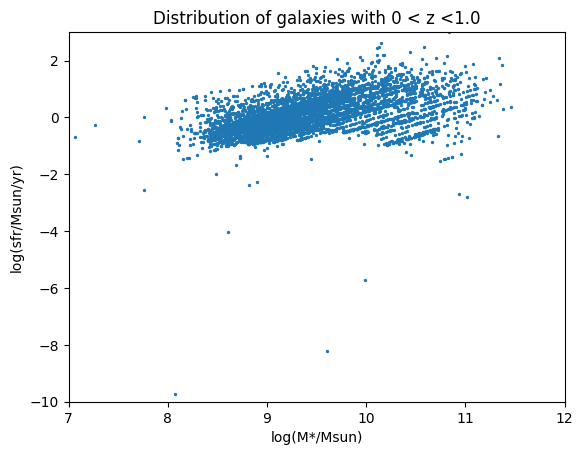

In [16]:
lmass_z1 = table_z1_active['lmass']
lsfr_z1 = table_z1_active['lsfr']
specsfr_z1 = lsfr_z1 - lmass_z1

plt.scatter(lmass_z1, lsfr_z1, s = 2)
plt.xlabel('log(M*/Msun)')
plt.ylabel('log(sfr/Msun/yr)')
plt.ylim(-10.0, 3.0)
plt.xlim(7, 12)
plt.title('Distribution of galaxies with 0 < z <1.0')

plt.show()

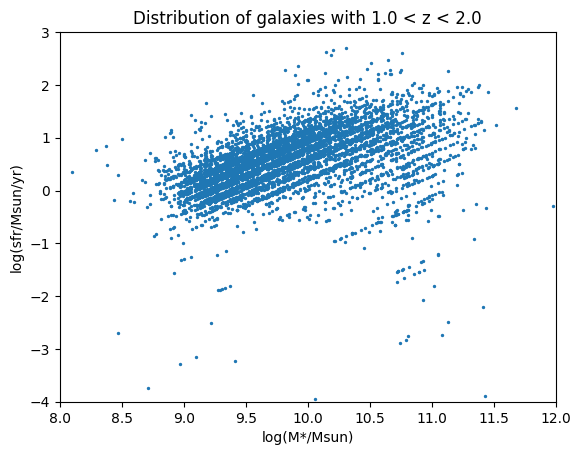

In [17]:
lmass_z2 = table_z2_active['lmass']
lsfr_z2 = table_z2_active['lsfr']
specsfr_z2 = lsfr_z2 - lmass_z2

plt.scatter(lmass_z2, lsfr_z2, s=2)
plt.xlabel('log(M*/Msun)')
plt.ylabel('log(sfr/Msun/yr)')
plt.ylim(-4.0, 3.0)
plt.xlim(8, 12)
plt.title('Distribution of galaxies with 1.0 < z < 2.0')

plt.show()

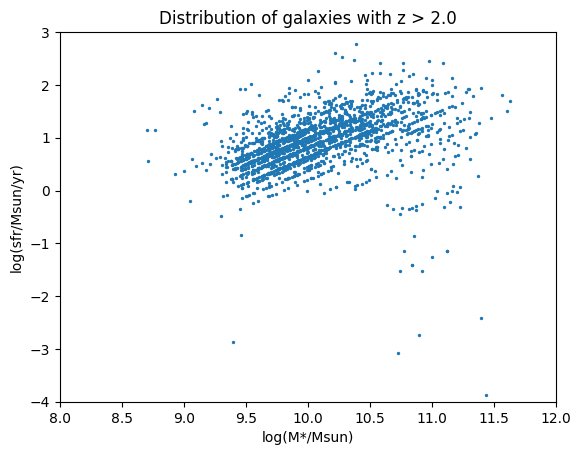

In [18]:
lmass_z3 = table_z3_active['lmass']
lsfr_z3 = table_z3_active['lsfr']
specsfr_z3 = lsfr_z3 - lmass_z3

plt.scatter(lmass_z3, lsfr_z3, s=2)
plt.xlabel('log(M*/Msun)')
plt.ylabel('log(sfr/Msun/yr)')
plt.ylim(-4, 3.0)
plt.xlim(8, 12)
plt.title('Distribution of galaxies with z > 2.0')

plt.show()

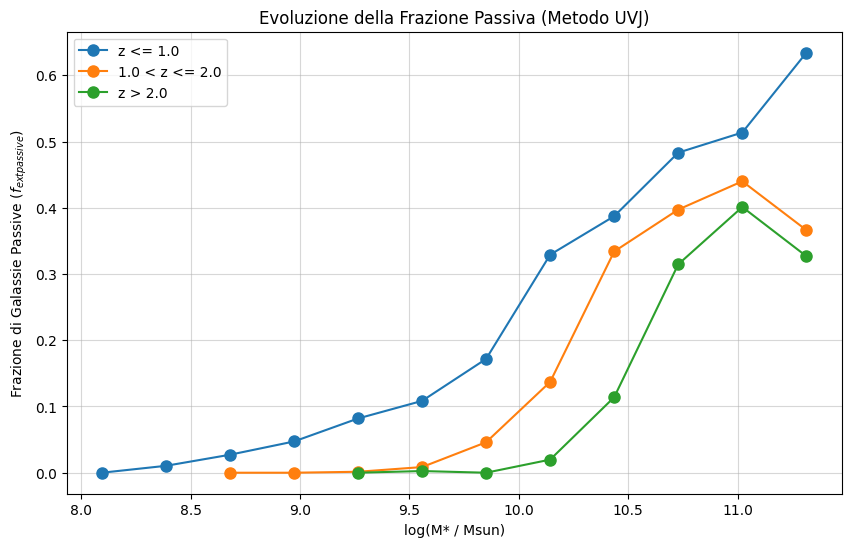

In [41]:
isto_z1= np.histogram(lmass_z1, bins = 15)
isto_z2= np.histogram(lmass_z2, bins = 15)
isto_z3= np.histogram(lmass_z3, bins = 15)

z1 = (table_clean['z_best'] > 0) & (table_clean['z_best'] <= 1.0) 
z2 = (table_clean['z_best'] > 1.0) & (table_clean['z_best'] <= 2.0) 
z3 = (table_clean['z_best'] > 2.0) 

table_z1 = table_clean[z1]
table_z2 = table_clean[z2]
table_z3 = table_clean[z3]

UmV_z1 = table_z1['UmV']
VmJ_z1 = table_z1['VmJ']
UmV_z2 = table_z2['UmV']
VmJ_z2 = table_z2['VmJ']
UmV_z3 = table_z3['UmV']
VmJ_z3 = table_z3['VmJ']

lmass_z1_tot = table_z1['lmass']
lmass_z2_tot = table_z2['lmass']
lmass_z3_tot = table_z3['lmass']


# Ciclo for per redshift z1
passive_fraction_z1 = [] # Lista vuota per i risultati
passive_fraction_z2 = []
passive_fraction_z3 = []
bordi = isto_z1[1]
mass_centers = (bordi[:-1] + bordi[1:]) / 2

for i in range(len(bordi)-1):
        m_low = bordi[i]
        m_high = bordi[i+1]
       
        mass_bin_mask = (lmass_z1_tot >= m_low) & (lmass_z1_tot < m_high)  #scelgo galassie in questo bin di massa

        UmV_in_bin = UmV_z1[mass_bin_mask] 
        VmJ_in_bin = VmJ_z1[mass_bin_mask]

        passive_mask_bin = (UmV_in_bin > 0.88 * VmJ_in_bin + 0.59) & (UmV_in_bin > 1.3) & (VmJ_in_bin < 1.6) #maschera gal passive per questa fetta

        n_passive = np.sum(passive_mask_bin)

        if len(UmV_in_bin) < 10 :
            passive_fraction_z1.append(np.nan)  #questo si aggiunge perché altrimenti passive_fraction_z1 conterrà meno robe di mass_centers e il grafico non viene
            continue
    
        frac = n_passive / len(UmV_in_bin) 
        
        passive_fraction_z1.append(frac)

    
for i in range(len(bordi)-1):
        m_low = bordi[i]
        m_high = bordi[i+1]
       
        mass_bin_mask = (lmass_z2_tot >= m_low) & (lmass_z2_tot < m_high)  #scelgo galassie in questo bin di massa

        UmV_in_bin = UmV_z2[mass_bin_mask] 
        VmJ_in_bin = VmJ_z2[mass_bin_mask]

        passive_mask_bin = (UmV_in_bin > 0.88 * VmJ_in_bin + 0.59) & (UmV_in_bin > 1.3) & (VmJ_in_bin < 1.6) #maschera gal passive per questa fetta

        n_passive = np.sum(passive_mask_bin)

        if len(UmV_in_bin) < 10 :
            passive_fraction_z2.append(np.nan)
            continue
        
        frac = n_passive / len(UmV_in_bin) 
        
        passive_fraction_z2.append(frac)
        

for i in range(len(bordi)-1):
        m_low = bordi[i]
        m_high = bordi[i+1]
       
        mass_bin_mask = (lmass_z3_tot >= m_low) & (lmass_z3_tot < m_high)  #scelgo galassie in questo bin di massa

        UmV_in_bin = UmV_z3[mass_bin_mask] 
        VmJ_in_bin = VmJ_z3[mass_bin_mask]

        passive_mask_bin = (UmV_in_bin > 0.88 * VmJ_in_bin + 0.59) & (UmV_in_bin > 1.3) & (VmJ_in_bin < 1.6) #maschera gal passive per questa fetta

        n_passive = np.sum(passive_mask_bin)

        if len(UmV_in_bin) < 10 :
            passive_fraction_z3.append(np.nan)
            continue
        
        frac = n_passive / len(UmV_in_bin) 
        
        passive_fraction_z3.append(frac)


plt.figure(figsize=(10, 6))

# Plottiamo i 3 risultati sullo stesso grafico
plt.plot(mass_centers, passive_fraction_z1, 'o-', label=f'z <= 1.0', markersize=8)
plt.plot(mass_centers, passive_fraction_z2, 'o-', label=f'1.0 < z <= 2.0', markersize=8)
plt.plot(mass_centers, passive_fraction_z3, 'o-', label=f'z > 2.0', markersize=8)

# Formattazione
plt.xlabel('log(M* / Msun)')
plt.ylabel('Frazione di Galassie Passive ($f_{\text{passive}}$)')
plt.title('Evoluzione della Frazione Passiva (Metodo UVJ)')

#plt.xlim(8.0, 11.5)
#plt.ylim(-0.5, 0.8) # La frazione è sempre tra 0 e 1
plt.grid(True, alpha=0.5)
plt.legend()
plt.savefig('passive_fraction_evolution_UVJ.png', dpi=300, bbox_inches='tight')
plt.show()